# Running Palace Simulations

[Palace](https://awslabs.github.io/palace/) is an open-source 3D electromagnetic simulator supporting eigenmode, driven (S-parameter), and electrostatic simulations. This notebook demonstrates using the `gsim.palace` API to run a driven simulation on a CPW (coplanar waveguide) structure.

**Requirements:**

- IHP PDK: `uv pip install ihp-gdsfactory`
- [GDSFactory+](https://gdsfactory.com) account for cloud simulation

### Load a pcell from IHP PDK

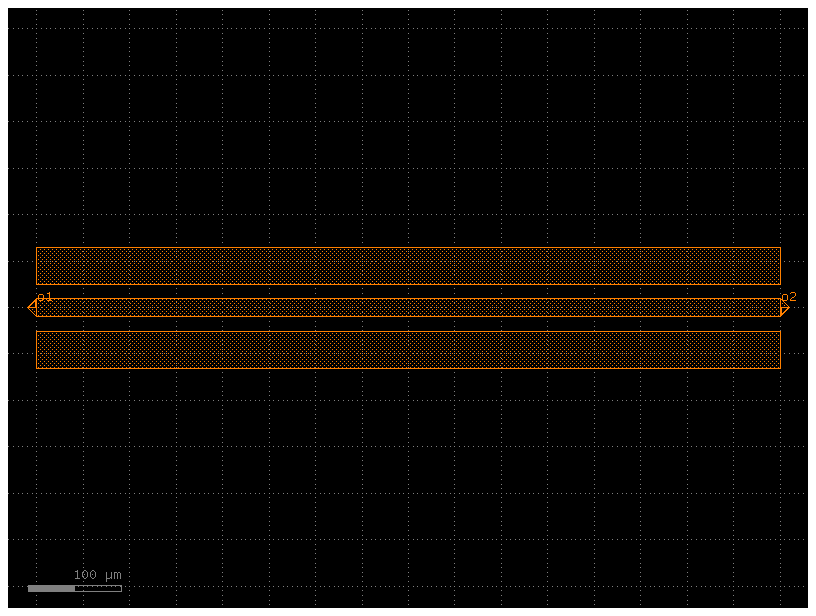

In [2]:
import gdsfactory as gf
from ihp import LAYER, PDK

PDK.activate()


@gf.cell
def gsg_electrode(
    length: float = 800,
    s_width: float = 20,
    g_width: float = 40,
    gap_width: float = 15,
    layer=LAYER.TopMetal2drawing,
) -> gf.Component:
    """
    Create a GSG (Ground-Signal-Ground) electrode.

    Args:
        length: horizontal length of the electrodes
        s_width: width of the signal (center) electrode
        g_width: width of the ground electrodes
        gap_width: gap between signal and ground electrodes
        layer: layer for the metal
    """
    c = gf.Component()

    # Top ground electrode
    r1 = c << gf.c.rectangle((length, g_width), centered=True, layer=layer)
    r1.move((0, (g_width + s_width) / 2 + gap_width))

    # Center signal electrode
    _r2 = c << gf.c.rectangle((length, s_width), centered=True, layer=layer)

    # Bottom ground electrode
    r3 = c << gf.c.rectangle((length, g_width), centered=True, layer=layer)
    r3.move((0, -(g_width + s_width) / 2 - gap_width))

    # Add ports at the signal center (one per side)
    # The CPW port API computes the gap element surfaces from s_width and gap_width
    c.add_port(
        name="o1",
        center=(-length / 2, 0),
        width=s_width,
        orientation=180,
        port_type="electrical",
        layer=layer,
    )

    c.add_port(
        name="o2",
        center=(length / 2, 0),
        width=s_width,
        orientation=0,
        port_type="electrical",
        layer=layer,
    )

    return c


c = gsg_electrode()
cc = c.copy()
cc.draw_ports()
cc

### Configure and run simulation with DrivenSim

In [3]:
from gsim.palace import DrivenSim

# Create simulation object
sim_lumped = DrivenSim()

# Set output directory
sim_lumped.set_output_dir("./palace-sim-cpw")

# Set the component geometry
sim_lumped.set_geometry(c)

# Configure layer stack from active PDK
sim_lumped.set_stack(substrate_thickness=2.0, air_above=300.0)

# Configure left CPW port (single port at signal center)
sim_lumped.add_cpw_port(
    "o1",
    layer="topmetal2",
    s_width=20,
    gap_width=15,
    length=5.0,
    offset=2.5,
    excited=True,
)

# Configure right CPW port (single port at signal center)
sim_lumped.add_cpw_port(
    "o2",
    layer="topmetal2",
    s_width=20,
    gap_width=15,
    length=5.0,
    offset=2.5,
    excited=False,
)

# Configure driven simulation (frequency sweep for S-parameters)
sim_lumped.set_driven(fmin=1e9, fmax=100e9, num_points=300)

# Validate configuration
print(sim_lumped.validate_config())

Validation: PASSED


### Configure simulation with DrivenSim for WavePorts

In [ ]:
# Create simulation object
sim_waveport = DrivenSim()

# Set output directory
sim_waveport.set_output_dir("./palace-sim-cpw-waveport")

# Set the component geometry
sim_waveport.set_geometry(c)

# Configure layer stack from active PDK
sim_waveport.set_stack(substrate_thickness=2.0, air_above=200.0)

# Configure left CPW port (single port at signal center)
sim_waveport.add_wave_port("o1", layer="topmetal2", max_size=True, mode=1, excited=True)

# Configure right CPW port (single port at signal center)
sim_waveport.add_wave_port(
    "o2", layer="topmetal2", max_size=True, mode=1, excited=False
)

# Configure driven simulation (frequency sweep for S-parameters)
sim_waveport.set_driven(fmin=1e9, fmax=100e9, num_points=300)

# Validate configuration
print(sim_waveport.validate_config())

Validation: PASSED


In [ ]:
# Generate mesh with planar conductors (presets: "coarse", "default", "fine")
sim_lumped.mesh(preset="coarse", planar_conductors=False, margin=50.0)
sim_waveport.mesh(preset="coarse", planar_conductors=False, margin_x=0, margin_y=50.0)

Mesh Summary
Dimensions: 800.0 x 230.0 x 218.3 µm
Nodes:      11,517
Elements:   83,495
Tetrahedra: 59,041
Edge length: 0.40 - 170.78 µm
Quality:    0.467 (min: 0.001)
SICN:       0.514 (all valid)
----------------------------------------
Volumes (3):
  - SiO2 [1]
  - passive [2]
  - air [3]
Surfaces (9):
  - topmetal2_xy [4]
  - topmetal2_z [5]
  - P1 [6]
  - P2 [7]
  - SiO2__None [8]
  - SiO2__passive [9]
  - passive__None [10]
  - air__passive [11]
  - air__None [12]
----------------------------------------
Mesh:   palace-sim-cpw-waveport/palace.msh

In [12]:
# Solid view — coloured surfaces per physical group, boundary transparent
sim_lumped.plot_mesh(
    style="solid",
    transparent_groups=["air__None", "SiO2__None", "SiO2__passive", "air__passive"],
    interactive=True,
)

# Solid view — coloured surfaces per physical group, boundary transparent
sim_waveport.plot_mesh(
    style="solid",
    transparent_groups=["air__None", "SiO2__None", "SiO2__passive", "air__passive"],
    interactive=True,
)

Widget(value='<iframe src="http://localhost:45381/index.html?ui=P_0x73d2f2f99370_2&reconnect=auto" class="pyvi…

Widget(value='<iframe src="http://localhost:45381/index.html?ui=P_0x73d29c74b770_3&reconnect=auto" class="pyvi…

### Run simulation on cloud

In [8]:
# Run driven simulation with lumped ports on GDSFactory+ cloud
sim_lumped.write_config()
results_lumped = sim_lumped.run_local(palace_sif_path="~/palace/Palace.sif")

In [11]:
# Run driven simulation with waveports on GDSFactory+ cloud
sim_waveport.write_config()
results_waveport = sim_waveport.run_local(palace_sif_path="~/palace/Palace.sif")

RuntimeError: Palace simulation failed with return code 1

Stdout:
>> /usr/lib64/mpich/bin/mpirun -n 1 /opt/palace/bin/palace-x86_64.bin config.json

_____________     _______
_____   __   \____ __   /____ ____________
____   /_/  /  __ ` /  /  __ ` /  ___/  _ \
___   _____/  /_/  /  /  /_/  /  /__/  ___/
  /__/     \___,__/__/\___,__/\_____\_____/


[38;2;255;255;000m--> Warning![0m
Output folder is not empty; program will overwrite content! (output/palace)
Git changeset ID: v0.16.0-34-gea2e7b23
Running with 1 MPI process, 1 OpenMP thread
Device configuration: omp,cpu
Memory configuration: host-std
libCEED backend: /cpu/self/xsmm/blocked

Added 5244 duplicate vertices for interior boundaries in the mesh
Added 10396 duplicate boundary elements for interior boundaries in the mesh
Finished partitioning mesh into 1 subdomain

Characteristic length and time scales:
 Lc = 8.000e-04 m, tc = 2.669e-03 ns

Mesh curvature order: 1
Mesh bounding box:
 (Xmin, Ymin, Zmin) = (-4.000e-04, -1.150e-

In [ ]:
import matplotlib.pyplot as plt
from gsim.palace import load_sparams

sp_lumped = load_sparams(results_lumped)
sp_waveport = load_sparams(results_waveport)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))

for label, sp in sp_lumped._filtered_entries(full=False):
    ax1.plot(sp_lumped.freq, sp.db, label=f"{label} (lumped)")
    ax2.plot(sp_lumped.freq, sp.deg, label=f"{label} (lumped)")

for label, sp in sp_waveport._filtered_entries(full=False):
    ax1.plot(sp_waveport.freq, sp.db, "--", label=f"{label} (waveport)")
    ax2.plot(sp_waveport.freq, sp.deg, "--", label=f"{label} (waveport)")

ax1.set_ylabel("Magnitude (dB)")
ax1.set_title("S-Parameters — Lumped vs Waveport")
ax1.legend()
ax1.grid(True)

ax2.set_xlabel("Frequency (GHz)")
ax2.set_ylabel("Phase (deg)")
ax2.legend()
ax2.grid(True)

fig.tight_layout()
plt.show()